In [84]:
import sys
sys.path.insert(0, '..')

In [85]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import matplotlib as mpl

import interpax as ipx


In [86]:
def plot_diffraction_limit(wl, diam, ax=None, OOP=False):
    """Plot a scale bar showing the diffraction limit (lambda / D).

    Parameters
    ----------
    model
        Object exposing ``source_spectrum`` and ``optics.diameter`` used to
        compute an effective wavelength and the diffraction-limited scale.
    ax : matplotlib.axes.Axes, optional
        Axis to draw onto. If not provided, the function draws to the current
        pyplot axes.
    OOP : bool, optional
        If True and ``ax`` is provided, draw the bar on the supplied axis and
        return the axis.
    """
    effective_wl = wl
    diff_lim = dlu.rad2arcsec(effective_wl / diam)
    scale_length = diff_lim

    scale_bar_x = -0.7
    scale_bar_y = scale_bar_x
    fontdict = {
        "fontstyle": "normal",
        "color": "hotpink",
        "weight": "demi",
        "size": 7,
    }

    if OOP and ax is not None:
        ax.plot(
            [scale_bar_x, scale_bar_x + scale_length],
            [scale_bar_y, scale_bar_y],
            color="hotpink",
            linewidth=2,
        )
        ax.text(
            scale_bar_x + scale_length / 2 - 0.075,
            scale_bar_y + 0.03,
            r"$\lambda / D$",
            **fontdict,
        )
        return ax

    else:
        plt.plot(
            [scale_bar_x, scale_bar_x + scale_length],
            [scale_bar_y, scale_bar_y],
            color="hotpink",
            linewidth=2,
        )
        plt.text(
            scale_bar_x + scale_length / 2 - 0.046,
            scale_bar_y + 0.02,
            r"$\lambda / D$",
            **fontdict,
        )


def get_arcsec_extents(pixel_scale, shape):
    """Return axis extents in arcseconds for use with ``imshow``.

    Parameters
    ----------
    pixel_scale : float
        Pixel scale in arcseconds per pixel.
    shape : tuple
        Shape of the image (ny, nx) or (n, n). The function uses the first
        axis length to compute the extent.
    """
    return np.array([0.5, -0.5, -0.5, 0.5]) * pixel_scale * shape[0]

def plot_result(
    ax,
    array,
    pixel_scale,
    roll_angle_degrees: float = None,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    norm=mpl.colors.PowerNorm(1, vmin=0, vmax=None),
    diff_lim: float = None,
    occulter: float = None,
    star = None,
    scale=1.0,
    translate=(0.0, 0.0),
    ticks=[0.5, 0, -0.5],
):
    """Convenience wrapper to display an image with sensible defaults.

    This helper sets axis labels, background colour, computes an extent in
    arcseconds from the provided `pixel_scale` and applies optional rotation
    and scaling to the resulting image artist.
    """

    ax.set_facecolor(bg_color)  # Set the background colour
    ax.tick_params(direction="out")
    ax.set(
        xticks=ticks,
        yticks=ticks[::-1],
        **axis_labels,
    )  # Set the axis labels

    kwargs = {
        "extent": get_arcsec_extents(pixel_scale / scale, array.shape[:2]),
        "norm": norm,
        "aspect": "equal",
    }

    if cmap:
        kwargs["cmap"] = cmap

    im = ax.imshow(
        array,
        **kwargs,
    )

    if diff_lim is not None:

        centre = 0.95 * np.array(kwargs["extent"][0:2]) + np.array([-diff_lim, diff_lim])

        beam = mpl.patches.Circle(
            centre,
            radius=diff_lim,
            facecolor="white",
            edgecolor="black",
            alpha=0.7,
            zorder=10,
        )
        ax.add_patch(beam)
    
    if occulter is not None:

        centre = np.zeros(2)#+1#np.array(kwargs["extent"][0:2])

        beam = mpl.patches.Circle(
            centre,
            radius=occulter,
            facecolor="black",
            edgecolor="white",
            alpha=0.7,
            zorder=1,
        )
        ax.add_patch(beam)

    if star:
        plt.scatter(0, 0, marker='*', s=1000, c='gold', edgecolor='black')

    if roll_angle_degrees is not None or scale is not None:

        if scale is None:
            scale = 1.0
        if roll_angle_degrees is None:
            roll_angle_degrees = 0.0

        rotation_transform = (
            mpl.transforms.Affine2D()
            .rotate_deg(roll_angle_degrees)
            .scale(scale)
            .translate(*translate)
        )  # Create a rotation transformation
        trans_data = rotation_transform + ax.transData  # creating transformation
        im.set_transform(trans_data)  # applying transformation to image

    return im

In [87]:
data = (10**np.load("../batch/imlup.npy"))#**0.8

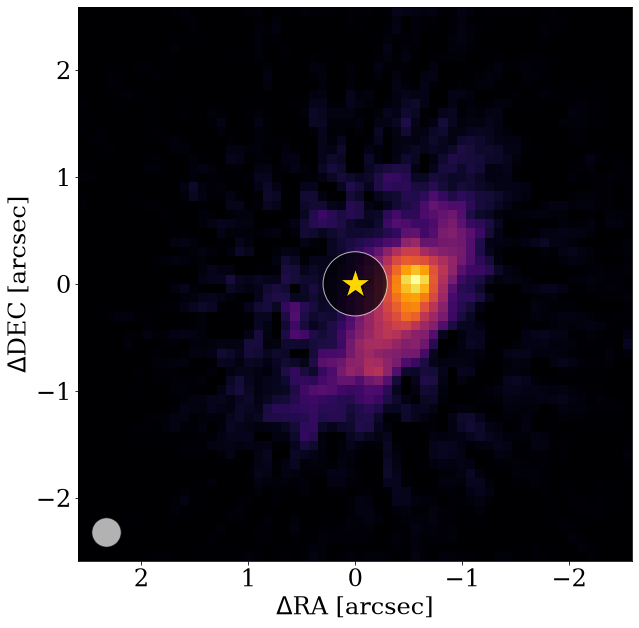

In [88]:
fig, axs = plt.subplots(1,1, figsize=(10,10))
plot_result(axs, data, 0.0432*2, cmap="inferno", diff_lim=dlu.rad2arcsec(1.6e-6/2.4), ticks=[-2,-1,0,1,2], occulter=0.3, star=True)